# Code to analyze CR2 station data and CAMELS-CL gridded basin data for the Itata Basin (Nevados de Chillán)
## Precipitation, temperature, and streamflow

### CR2 station data can be found here: https://explorador.cr2.cl/
### MAWÜN precip product comparisons here: https://mawun.cr2.cl

In [4]:
##################### IMPORT PACKAGES #####################
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np
import pymannkendall as mk
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
from datetime import datetime
from geopy.distance import geodesic
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

# to use R in ipynb
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector  # <- correct import

utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)  # pick a CRAN mirror

packnames = ['ecp']
names_to_install = [x for x in packnames if not rpackages.isinstalled(x)]
if names_to_install:
    utils.install_packages(StrVector(names_to_install))  # <- use StrVector here



CAMELS-CL data is a gridded, basin-wide product. Here, we compare point-scale station measurements to the gridded basin-wide product, and finally to the particular grid cell over the glaciers. 

## MAWUN precip comparison: (https://mawun.cr2.cl)
### Compares station data with CR2MET, IMERG, ERA5, CHIRPS, MSWEP, MSWX, and CMORPH

## First for Estación Diguillín 

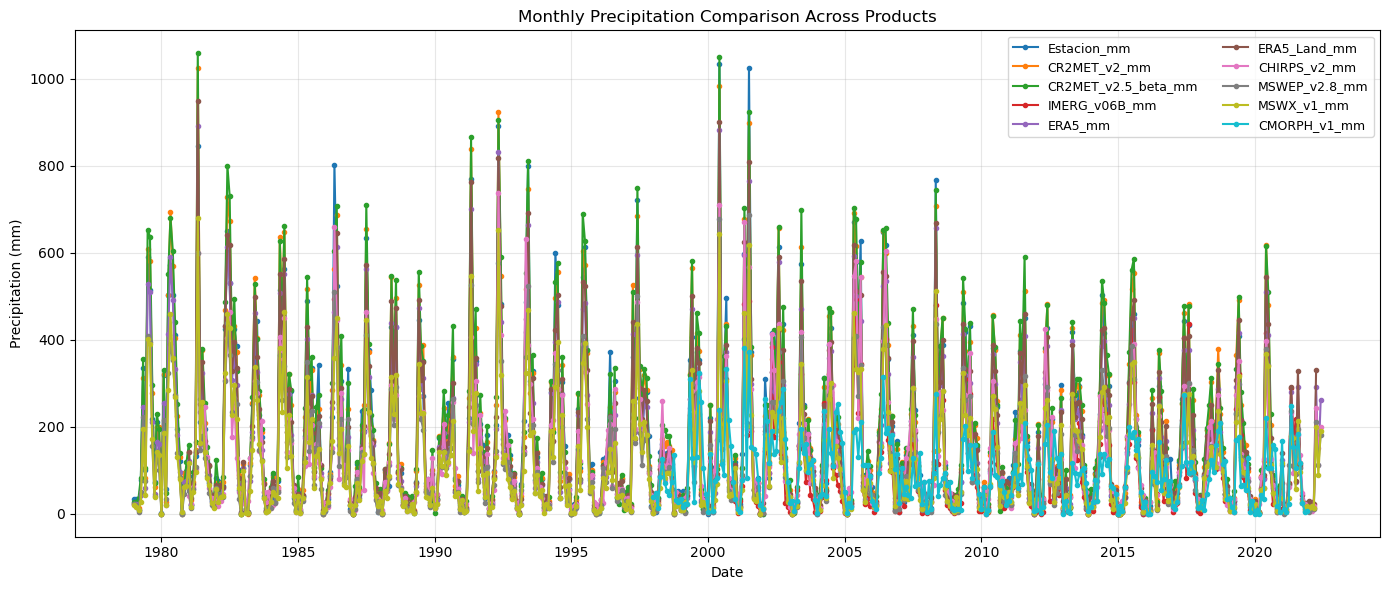

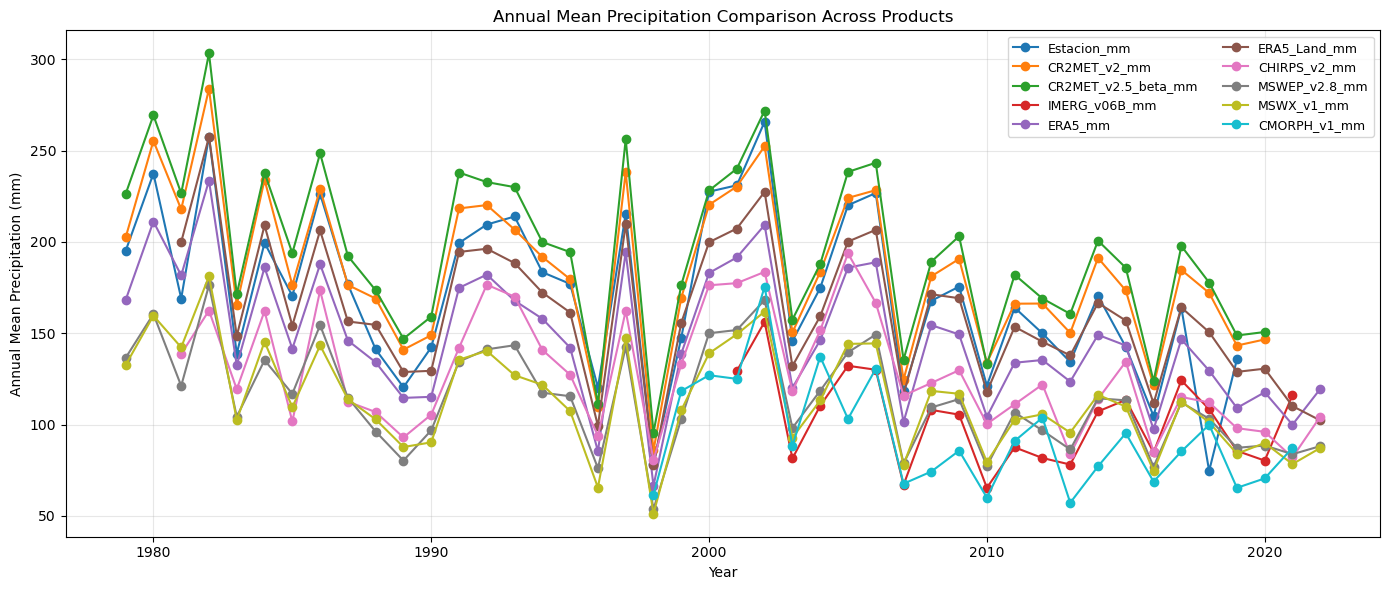


=== Mean Bias (mm) relative to reference station ===
Estacion_mm             0.000000
CR2MET_v2_mm           13.993496
CR2MET_v2.5_beta_mm    24.971138
IMERG_v06B_mm         -59.509649
ERA5_mm               -21.223984
ERA5_Land_mm           -4.583761
CHIRPS_v2_mm          -38.158547
MSWEP_v2.8_mm         -55.179268
MSWX_v1_mm            -55.597967
CMORPH_v1_mm          -65.576515
dtype: float64

Interpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.

=== RMSE (mm) relative to reference station ===
CR2MET_v2_mm           22.921954
CR2MET_v2.5_beta_mm    30.512513
IMERG_v06B_mm          67.312720
ERA5_mm                27.808361
ERA5_Land_mm           19.433517
CHIRPS_v2_mm           44.849053
MSWEP_v2.8_mm          58.959312
MSWX_v1_mm             59.968919
CMORPH_v1_mm           73.491687
dtype: float64

Interpretation: Lower RMSE indicates better agreement with the reference station.

=== Correlation with reference s

In [5]:
# ------------------ FILE PATH ------------------
file_path = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv"

# ------------------ LOAD DATA ------------------
# Read CSV with latin-1 encoding
df = pd.read_csv(file_path, encoding="latin-1")

# Replace missing value code (-9999) with NaN
df.replace(-9999, np.nan, inplace=True)

# Convert 'Fecha' column to datetime (monthly frequency)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m')

# Identify precipitation products (all columns except 'Fecha')
products = [col for col in df.columns if col != 'Fecha']

# ------------------ MONTHLY TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(df['Fecha'], df[prod], label=prod, marker='o', markersize=3)

plt.title("Monthly Precipitation Comparison Across Products")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ ANNUAL AGGREGATION ------------------
# Extract year from date
df['year'] = df['Fecha'].dt.year

# Compute annual mean for each product
annual_df = df.groupby('year')[products].mean()

# ------------------ ANNUAL TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(annual_df.index, annual_df[prod], marker='o', label=prod)

plt.title("Annual Mean Precipitation Comparison Across Products")
plt.xlabel("Year")
plt.ylabel("Annual Mean Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ QUANTITATIVE COMPARISON ------------------
reference = 'Estacion_mm'  # Use station measurements as reference

# ---- 1. Mean Bias ----
# Difference between each product and reference station
bias = annual_df.subtract(annual_df[reference], axis=0)
mean_bias = bias.mean()  # Average bias over all years
print("\n=== Mean Bias (mm) relative to reference station ===")
print(mean_bias)
print("\nInterpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.")

# ---- 2. RMSE ----
# Root Mean Squared Error relative to reference station
rmse_corrected = {}
for prod in products:
    if prod != reference:
        valid = annual_df[[reference, prod]].dropna()
        rmse_corrected[prod] = np.sqrt(np.mean((valid[prod] - valid[reference])**2))

rmse_corrected = pd.Series(rmse_corrected)
print("\n=== RMSE (mm) relative to reference station ===")
print(rmse_corrected)
print("\nInterpretation: Lower RMSE indicates better agreement with the reference station.")

# ---- 3. Correlation ----
# Pearson correlation coefficient relative to reference station
corr = annual_df.corr()[reference]
print("\n=== Correlation with reference station ===")
print(corr)
print("\nInterpretation: Values closer to 1 indicate stronger linear agreement with the station.")



### Here MSWEP performs best, followed by CR2MET 2.5 beta and then MSWX, ERA5 ... 

## Now for Estación Las Trancas

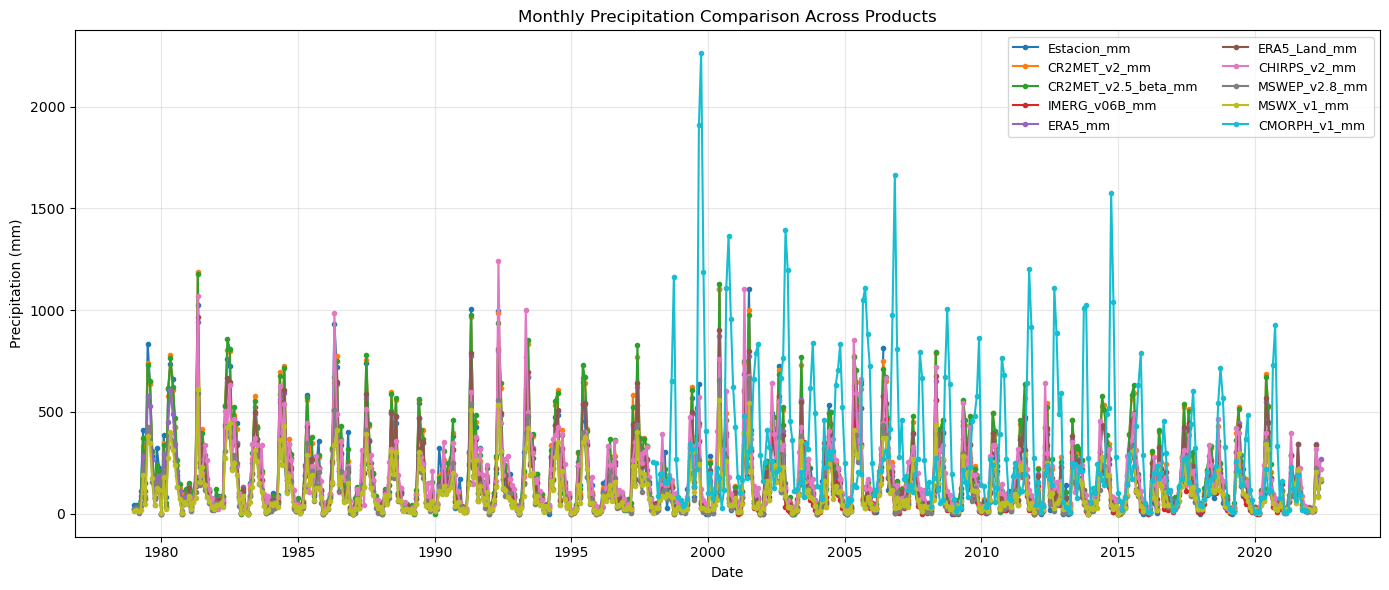

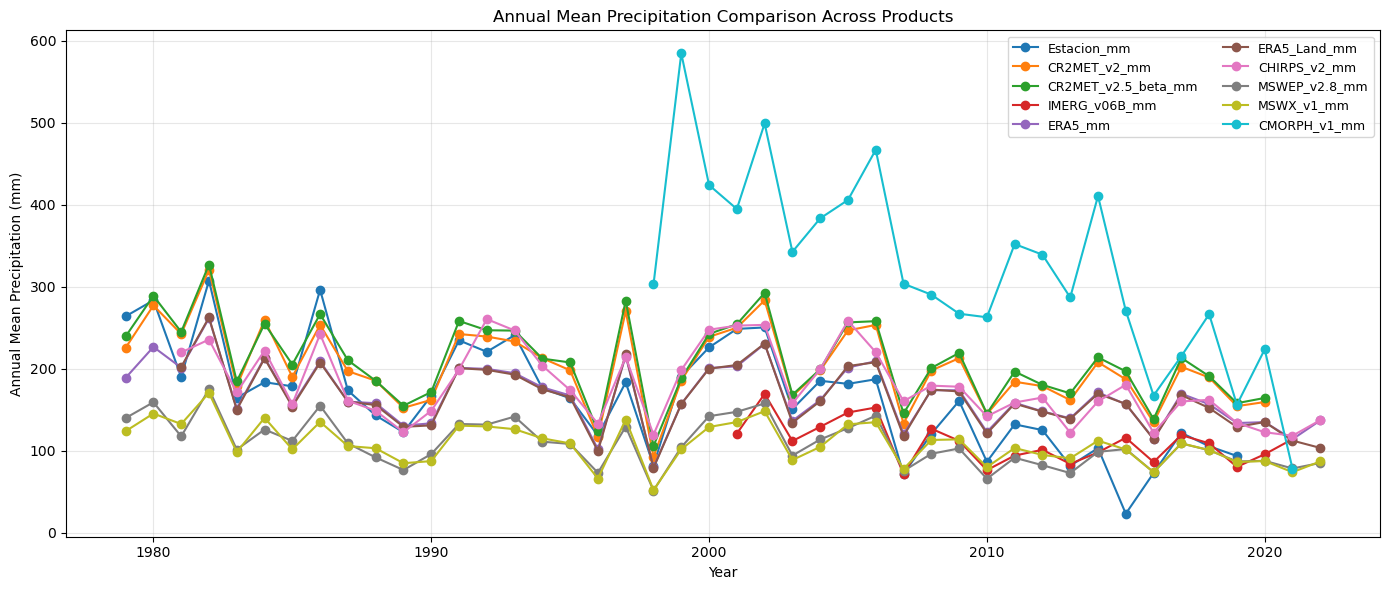


=== Mean Bias (mm) relative to reference station ===
Estacion_mm              0.000000
CR2MET_v2_mm            37.765001
CR2MET_v2.5_beta_mm     44.693863
IMERG_v06B_mm          -20.894463
ERA5_mm                  3.754838
ERA5_Land_mm             6.276454
CHIRPS_v2_mm            23.742266
MSWEP_v2.8_mm          -55.759389
MSWX_v1_mm             -55.730934
CMORPH_v1_mm           199.568418
dtype: float64

Interpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.

=== RMSE (mm) relative to reference station ===
CR2MET_v2_mm            54.837253
CR2MET_v2.5_beta_mm     59.205981
IMERG_v06B_mm           47.810805
ERA5_mm                 42.710408
ERA5_Land_mm            40.873321
CHIRPS_v2_mm            45.567445
MSWEP_v2.8_mm           70.117616
MSWX_v1_mm              73.944028
CMORPH_v1_mm           212.683833
dtype: float64

Interpretation: Lower RMSE indicates better agreement with the reference station.

=== Correlati

In [6]:
# ------------------ FILE PATH ------------------
file_path = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"

# ------------------ LOAD DATA ------------------
# Read CSV with latin-1 encoding
df = pd.read_csv(file_path, encoding="latin-1")

# Replace missing value code (-9999) with NaN
df.replace(-9999, np.nan, inplace=True)

# Convert 'Fecha' column to datetime (monthly frequency)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m')

# Identify precipitation products (all columns except 'Fecha')
products = [col for col in df.columns if col != 'Fecha']

# ------------------ MONTHLY TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(df['Fecha'], df[prod], label=prod, marker='o', markersize=3)

plt.title("Monthly Precipitation Comparison Across Products")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ ANNUAL AGGREGATION ------------------
# Extract year from date
df['year'] = df['Fecha'].dt.year

# Compute annual mean for each product
annual_df = df.groupby('year')[products].mean()

# ------------------ ANNUAL TIME SERIES PLOT ------------------
plt.figure(figsize=(14,6))
for prod in products:
    plt.plot(annual_df.index, annual_df[prod], marker='o', label=prod)

plt.title("Annual Mean Precipitation Comparison Across Products")
plt.xlabel("Year")
plt.ylabel("Annual Mean Precipitation (mm)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ QUANTITATIVE COMPARISON ------------------
reference = 'Estacion_mm'  # Use station measurements as reference

# ---- 1. Mean Bias ----
# Difference between each product and reference station
bias = annual_df.subtract(annual_df[reference], axis=0)
mean_bias = bias.mean()  # Average bias over all years
print("\n=== Mean Bias (mm) relative to reference station ===")
print(mean_bias)
print("\nInterpretation: Positive values indicate overestimation; negative values indicate underestimation relative to the station.")

# ---- 2. RMSE ----
# Root Mean Squared Error relative to reference station
rmse_corrected = {}
for prod in products:
    if prod != reference:
        valid = annual_df[[reference, prod]].dropna()
        rmse_corrected[prod] = np.sqrt(np.mean((valid[prod] - valid[reference])**2))

rmse_corrected = pd.Series(rmse_corrected)
print("\n=== RMSE (mm) relative to reference station ===")
print(rmse_corrected)
print("\nInterpretation: Lower RMSE indicates better agreement with the reference station.")

# ---- 3. Correlation ----
# Pearson correlation coefficient relative to reference station
corr = annual_df.corr()[reference]
print("\n=== Correlation with reference station ===")
print(corr)
print("\nInterpretation: Values closer to 1 indicate stronger linear agreement with the station.")

### here MSWEP seems to perform best, followed by CR2MET v2.5 beta, same as above. However, all perform worse here compared to station data. 

## Trying changepoint analysis using R package ecp

In [7]:
%load_ext rpy2.ipython


Station: Diguillin 
No changepoints detected.

Station: Las Trancas 
Changepoints detected at indices:
[1] 325
Corresponding dates:
[1] "2006-11-01"


Loading required package: ecp
Loading required package: Rcpp


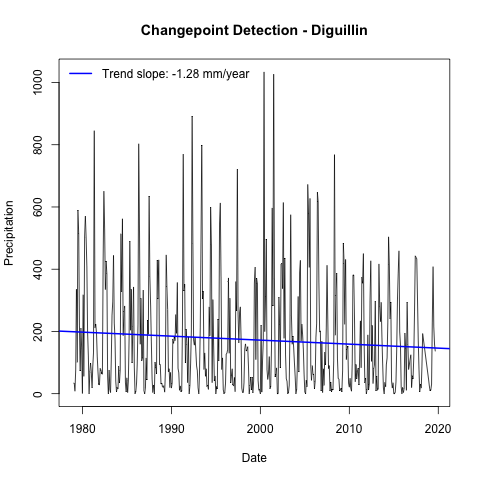

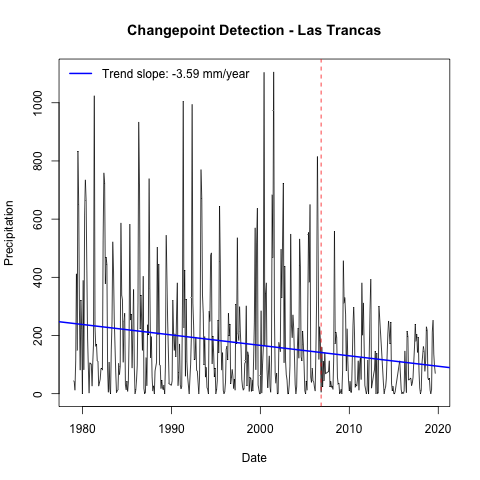

In [8]:
%%R
# Load/install ecp
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
library(ecp)

# Define the stations and file paths
stations <- list(
  "Diguillin" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
  "Las Trancas" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
)

# Loop over each station
for(station_name in names(stations)){
  
  file_path <- stations[[station_name]]
  
  # Load data
  data <- read.csv(file_path)
  
  # Extract precipitation and remove -9999
  precip <- data[,2]
  precip[precip == -9999] <- NA
  precip <- na.omit(precip)
  
  # Extract dates (adjust format as needed, here assuming YYYY-MM)
  dates <- as.Date(paste0(data[,1], "-01"), format="%Y-%m-%d")
  dates <- dates[!is.na(data[,2]) & data[,2] != -9999]
  
  # Run e.divisive changepoint detection
  set.seed(123)
  result <- e.divisive(matrix(precip, ncol=1), R=500, min.size=5)
  
  # Print results
  cat("\nStation:", station_name, "\n")
  if(length(result$estimates) <= 2){
    cat("No changepoints detected.\n")
  } else {
    changepoint_indices <- result$estimates[-c(1,length(result$estimates))] # remove first/last
    changepoint_dates <- dates[changepoint_indices]
    cat("Changepoints detected at indices:\n")
    print(changepoint_indices)
    cat("Corresponding dates:\n")
    print(changepoint_dates)
  }
  
  # Plot with actual dates on x-axis
  plot(dates, precip, type="l", main=paste("Changepoint Detection -", station_name),
       xlab="Date", ylab="Precipitation")
  
  # Add trendline
  trend_model <- lm(precip ~ as.numeric(dates))
  abline(trend_model, col="blue", lwd=2)
  slope <- coef(trend_model)[2] * 365  # slope in mm/year
  legend("topleft", legend=paste0("Trend slope: ", round(slope, 2), " mm/year"), 
         col="blue", lwd=2, bty="n")
  
  # Add changepoints if any
  if(length(result$estimates) > 2){
    abline(v=changepoint_dates, col="red", lty=2)
  }
}


## Therefore no changepoint identified for Diguillín station, but for Las Trancas Station November 2006 was a changepoint

## comparing modeled with measured precip products, still only Las Trancas station shows changepoint: 


Station: Diguillin Variable: Estacion_mm 
No changepoints detected.

Station: Diguillin Variable: CR2MET_v2_mm 
No changepoints detected.

Station: Diguillin Variable: CR2MET_v2.5_beta_mm 
No changepoints detected.

Station: Diguillin Variable: MSWEP_v2.8_mm 
No changepoints detected.

Station: Las Trancas Variable: Estacion_mm 
Changepoints detected at indices:
[1] 325
Corresponding dates:
[1] "2006-11"

Station: Las Trancas Variable: CR2MET_v2_mm 
No changepoints detected.

Station: Las Trancas Variable: CR2MET_v2.5_beta_mm 
No changepoints detected.

Station: Las Trancas Variable: MSWEP_v2.8_mm 
No changepoints detected.


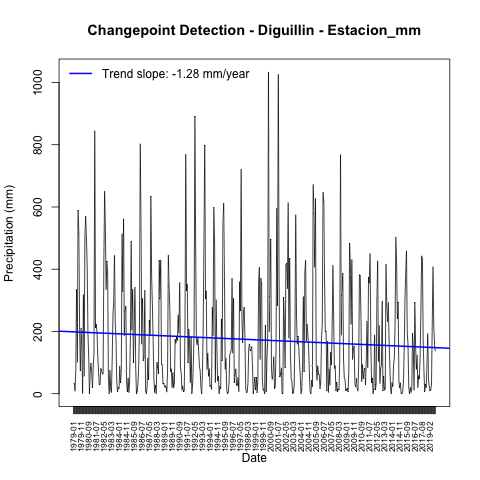

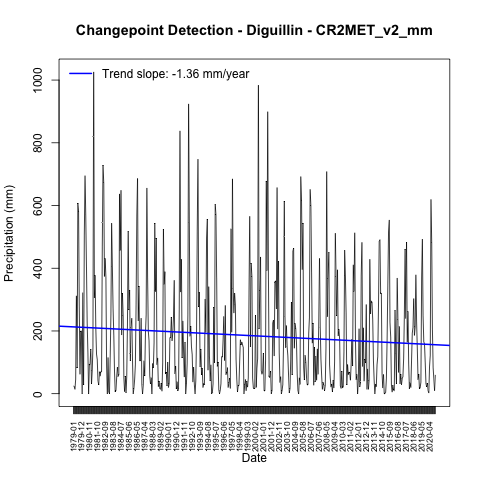

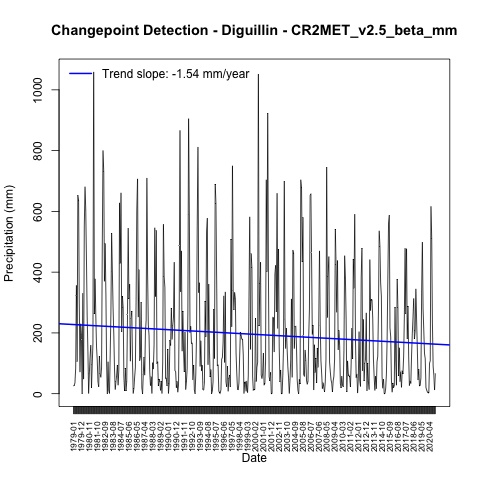

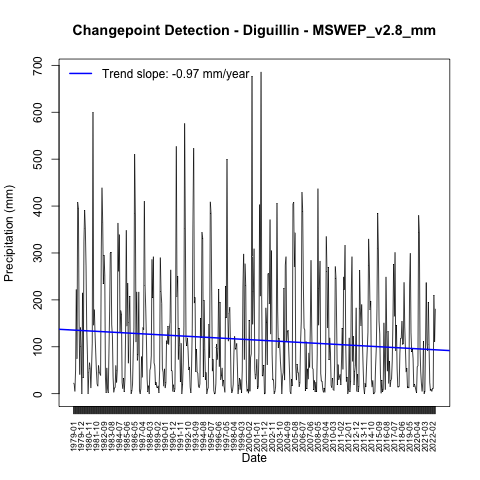

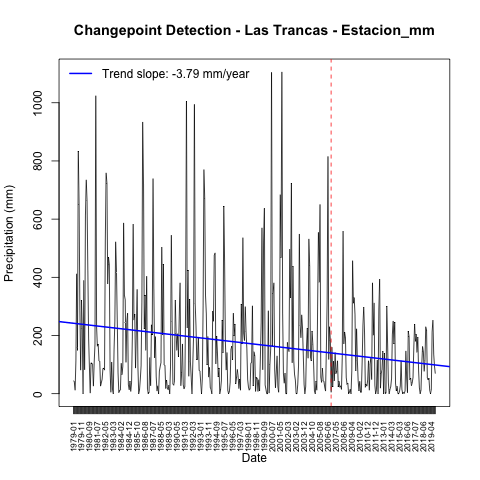

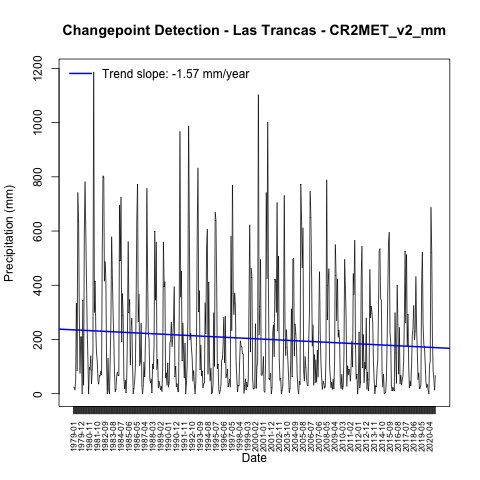

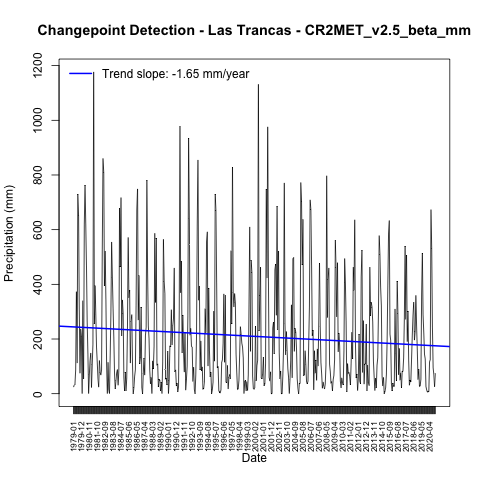

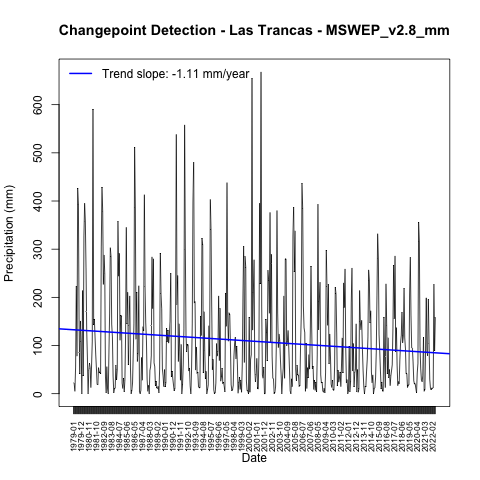

In [9]:
%%R
# ---------------------------------------------------------
# Changepoint Analysis for Monthly Precipitation Datasets
# ---------------------------------------------------------

if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
library(ecp)

stations <- list(
  "Diguillin" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
  "Las Trancas" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
)

variables <- c("Estacion_mm", "CR2MET_v2_mm", "CR2MET_v2.5_beta_mm", "MSWEP_v2.8_mm")

for(station_name in names(stations)){
  
  file_path <- stations[[station_name]]
  data <- read.csv(file_path, stringsAsFactors = FALSE)
  
  for(varname in variables){
    
    if(!varname %in% names(data)){
      cat("\nStation:", station_name, "Variable:", varname, "- not found, skipping.\n")
      next
    }
    
    # Extract variable and remove missing / -9999
    values <- as.numeric(data[[varname]])
    valid_idx <- !is.na(values) & values != -9999
    values <- values[valid_idx]
    
    # Use YYYY-MM as the date labels (no need to append day)
    dates <- data[valid_idx, 1]
    
    if(length(values) == 0){
      cat("\nStation:", station_name, "Variable:", varname, "- no valid data.\n")
      next
    }
    
    # Run e.divisive changepoint detection
    set.seed(123)
    result <- e.divisive(matrix(values, ncol=1), R=500, min.size=5)
    
    # Print results
    cat("\nStation:", station_name, "Variable:", varname, "\n")
    if(length(result$estimates) <= 2){
      cat("No changepoints detected.\n")
    } else {
      changepoint_indices <- result$estimates[-c(1,length(result$estimates))]
      changepoint_dates <- dates[changepoint_indices]
      cat("Changepoints detected at indices:\n")
      print(changepoint_indices)
      cat("Corresponding dates:\n")
      print(changepoint_dates)
    }
    
    # Plot
    plot(values, type="l", xaxt="n",
         main=paste("Changepoint Detection -", station_name, "-", varname),
         xlab="Date", ylab="Precipitation (mm)")
    axis(1, at=1:length(values), labels=dates, cex.axis=0.7, las=2)
    
    # Add trendline
    trend_model <- lm(values ~ seq_along(values))
    abline(trend_model, col="blue", lwd=2)
    slope <- coef(trend_model)[2] * 12  # convert monthly to yearly
    legend("topleft", legend=paste0("Trend slope: ", round(slope, 2), " mm/year"), 
           col="blue", lwd=2, bty="n")
    
    # Add changepoints if any
    if(length(result$estimates) > 2){
      abline(v=changepoint_indices, col="red", lty=2)
    }
  }
}


Now look at changepoint for min and max temperature at Diguillín (no temp recorded for Las Trancas). Computing monthly max and min temperatures by averaging daily. 


Station: Diguillin Tmax 
No changepoints detected.

Station: Diguillin Tmin 
No changepoints detected.


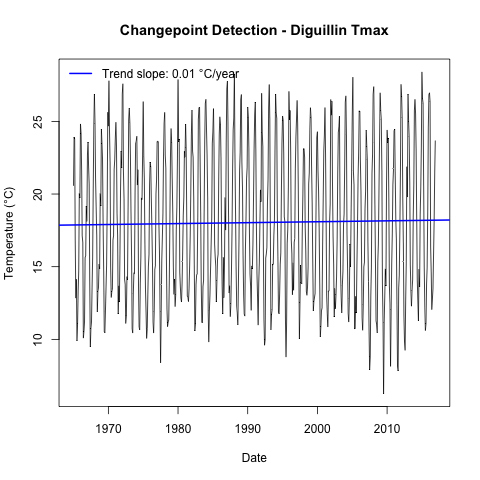

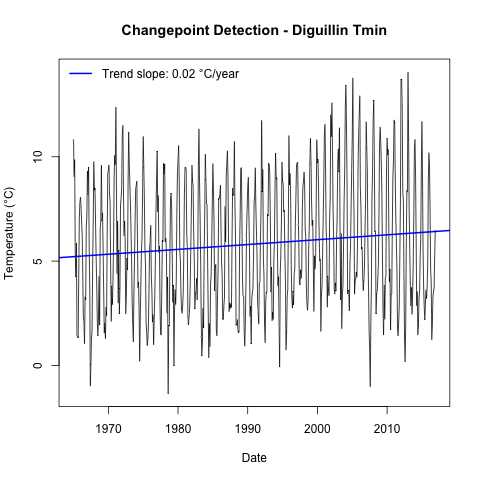

In [10]:
%%R
# ---------------------------------------------------------
# Changepoint Analysis for Min/Max Temperatures (Monthly)
# ---------------------------------------------------------

if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
library(ecp)

stations <- list(
  "Diguillin Tmax" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
  "Diguillin Tmin" = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
)

for(station_name in names(stations)) {
  
  file_path <- stations[[station_name]]
  
  # Load CSV with default comma separator
  data <- read.csv(file_path) 
  
  # Construct proper Date column using year/month/day
  data$date <- as.Date(paste(data$agno, data$mes, data$dia, sep="-"), format="%Y-%m-%d")
  
  # Convert value column to numeric and remove -9999
  temp <- as.numeric(data$valor)
  temp[temp == -9999] <- NA
  
  # Combine into dataframe and remove NA
  df <- data.frame(date = data$date, temp = temp)
  df <- df[!is.na(df$temp), ]
  
  # Skip if no valid data
  if(nrow(df) == 0){
    cat("No valid data for", station_name, "\n")
    next
  }
  
  # ------------------- Compute monthly averages -------------------
  df$year_month <- format(df$date, "%Y-%m")  # YYYY-MM string
  df_monthly <- aggregate(temp ~ year_month, data=df, FUN=mean)
  
  # Use first day of the month as representative date for plotting
  df_monthly$date <- as.Date(paste0(df_monthly$year_month, "-01"))
  temp <- df_monthly$temp
  dates <- df_monthly$date
  
  # Run changepoint detection
  set.seed(123)
  result <- e.divisive(matrix(temp, ncol=1), R=100, min.size=12)
  
  # Print results
  cat("\nStation:", station_name, "\n")
  if(length(result$estimates) <= 2){
    cat("No changepoints detected.\n")
  } else {
    changepoint_indices <- result$estimates[-c(1,length(result$estimates))] 
    changepoint_dates <- dates[changepoint_indices]
    cat("Changepoints detected at indices:\n")
    print(changepoint_indices)
    cat("Corresponding dates:\n")
    print(changepoint_dates)
  }
  
  # Plot
  plot(dates, temp, type="l", main=paste("Changepoint Detection -", station_name),
       xlab="Date", ylab="Temperature (°C)")
  
  # Add linear trend
  trend_model <- lm(temp ~ as.numeric(dates))
  abline(trend_model, col="blue", lwd=2)
  slope <- coef(trend_model)[2] * 365  # °C/year
  legend("topleft", legend=paste0("Trend slope: ", round(slope, 2), " °C/year"),
         col="blue", lwd=2, bty="n")
  
  # Add changepoints
  if(length(result$estimates) > 2){
    abline(v=changepoint_dates, col="red", lty=2)
  }
}


No changepoints found for temperature. Increasing trend for both min and max temperaures. Min temps increasing faster than max temps. 

## Finally, changepoint analysis for streamflow: 

Number of valid streamflow values: 475 
Station: Streamflow monthly
No changepoints detected.


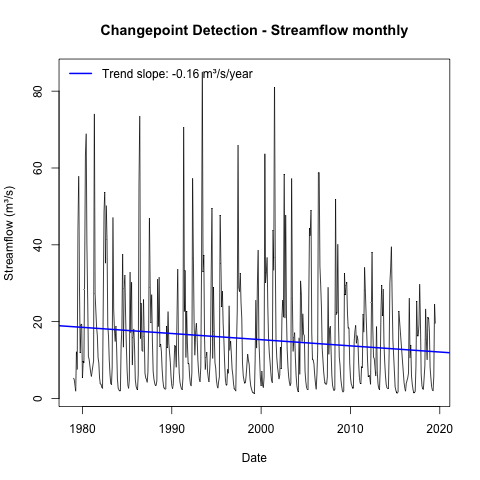

In [11]:
%%R
# Load/install ecp
if(!require(ecp)) install.packages("ecp", repos='http://cran.us.r-project.org')
library(ecp)

# File path
file_path <- "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/q_m3s_mon.csv"

# Load data
data <- read.csv(file_path, stringsAsFactors = FALSE)

# Extract streamflow by exact column name
q <- as.numeric(data[["X8130002"]])

# Construct dates from year/month
dates <- as.Date(paste(data$year, data$month, "01", sep="-"))

# Remove NAs
valid_idx <- !is.na(q)
q <- q[valid_idx]
dates <- dates[valid_idx]

# Check number of valid values
cat("Number of valid streamflow values:", length(q), "\n")

# Skip if no valid data
if(length(q) == 0){
  cat("No valid data to analyze.\n")
} else {
  
  # Run e.divisive changepoint detection with sensible min.size (e.g., 12 months)
  set.seed(123)
  result <- e.divisive(matrix(q, ncol=1), R=500, min.size=12)
  
  # Print results
  cat("Station: Streamflow monthly\n")
  if(length(result$estimates) <= 2){
    cat("No changepoints detected.\n")
  } else {
    changepoint_indices <- result$estimates[-c(1,length(result$estimates))] # remove first/last
    changepoint_dates <- dates[changepoint_indices]
    cat("Changepoints detected at indices:\n")
    print(changepoint_indices)
    cat("Corresponding dates:\n")
    print(changepoint_dates)
  }
  
  # Plot streamflow over time
  plot(dates, q, type="l", main="Changepoint Detection - Streamflow monthly",
       xlab="Date", ylab="Streamflow (m³/s)")
  
  # Add trendline
  trend_model <- lm(q ~ as.numeric(dates))
  abline(trend_model, col="blue", lwd=2)
  slope <- coef(trend_model)[2] * 365  # approximate slope per year
  legend("topleft", legend=paste0("Trend slope: ", round(slope, 2), " m³/s/year"), 
         col="blue", lwd=2, bty="n")
  
  # Add changepoints if any
  if(length(result$estimates) > 2){
    abline(v=changepoint_dates, col="red", lty=2)
  }
}


# Now looking at monthly, seasonal, and annual changes in station precip data


--- Diguillin ---


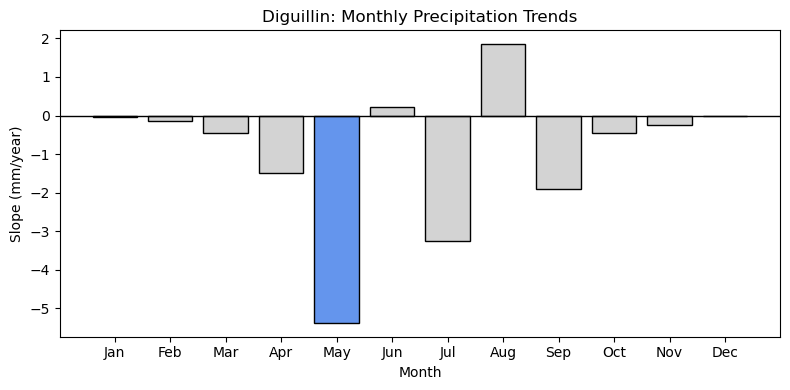


Month trends for Diguillin:
    month     slope   p_value  significant
0       1 -0.051316  0.660361        False
1       2 -0.149074  0.596873        False
2       3 -0.464103  0.285754        False
3       4 -1.494907  0.212491        False
4       5 -5.375000  0.082563         True
5       6  0.220982  0.916487        False
6       7 -3.250000  0.230974        False
7       8  1.847368  0.345109        False
8       9 -1.909091  0.156799        False
9      10 -0.454545  0.753201        False
10     11 -0.235294  0.820917        False
11     12  0.000000  0.925504        False


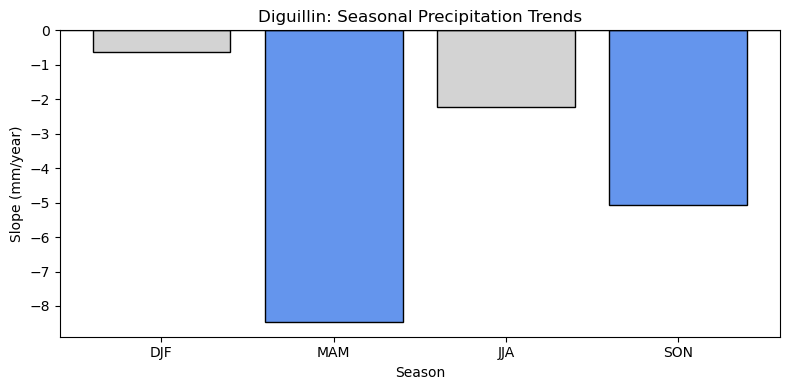


Season trends for Diguillin:
           slope   p_value  significant
season                                 
DJF    -0.641711  0.393222        False
MAM    -8.468750  0.009780         True
JJA    -2.238095  0.616375        False
SON    -5.077857  0.039159         True
Annual trend: slope=-22.20 mm/year, p=0.009, significant=True

--- Las Trancas ---


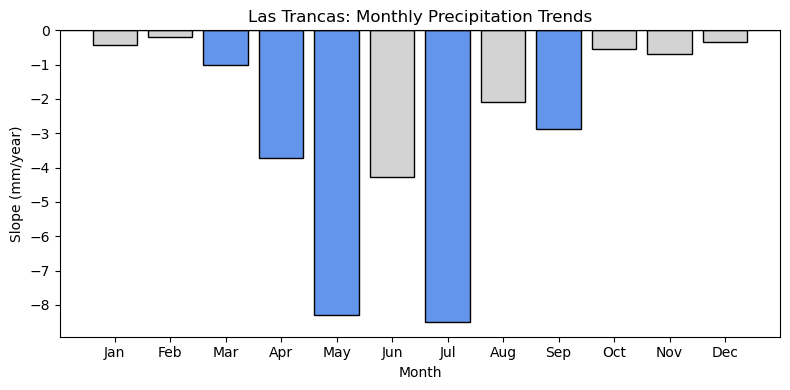


Month trends for Las Trancas:
    month     slope   p_value  significant
0       1 -0.414216  0.147189        False
1       2 -0.193750  0.381262        False
2       3 -1.000000  0.045255         True
3       4 -3.717105  0.019878         True
4       5 -8.300000  0.010017         True
5       6 -4.272727  0.222627        False
6       7 -8.500000  0.009471         True
7       8 -2.086957  0.352129        False
8       9 -2.866667  0.033083         True
9      10 -0.535714  0.637669        False
10     11 -0.679487  0.339452        False
11     12 -0.333333  0.418562        False


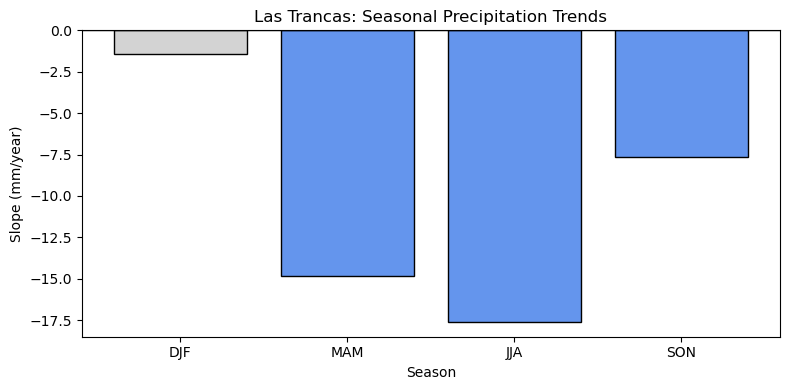


Season trends for Las Trancas:
            slope   p_value  significant
season                                  
DJF     -1.401515  0.156977        False
MAM    -14.849624  0.000024         True
JJA    -17.615385  0.001660         True
SON     -7.633333  0.010783         True
Annual trend: slope=-48.86 mm/year, p=0.000, significant=True


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk  # for Mann-Kendall trend test

# ------------------- FILE PATHS -------------------
stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

date_column = 'date'

# ------------------- FUNCTIONS -------------------

def load_data(filepath):
    """Load CSV and parse dates, removing missing values (-9999)."""
    df = pd.read_csv(filepath)
    df[date_column] = pd.to_datetime(df.iloc[:,0], errors='coerce')
    df['precip'] = df.iloc[:,1].replace(-9999, np.nan)
    df = df.dropna(subset=['precip', date_column])
    return df

def assign_season(df):
    """Assign season and year to each row."""
    df["month"] = df[date_column].dt.month
    df["year"] = df[date_column].dt.year
    df["season"] = df["month"].map({
        12:"DJF", 1:"DJF", 2:"DJF",
        3:"MAM", 4:"MAM", 5:"MAM",
        6:"JJA", 7:"JJA", 8:"JJA",
        9:"SON", 10:"SON", 11:"SON"
    })
    return df

def compute_monthly_trends(df):
    trends = []
    for month in range(1,13):
        series = df[df['month']==month].groupby('year')['precip'].sum()
        if len(series) > 10:
            test = mk.original_test(series)
            trends.append({
                "month": month,
                "slope": test.slope,
                "p_value": test.p,
                "significant": test.p < 0.1
            })
        else:
            trends.append({"month": month, "slope": np.nan, "p_value": np.nan, "significant": False})
    return pd.DataFrame(trends)

def compute_seasonal_trends(df):
    trends = []
    for season in ["DJF","MAM","JJA","SON"]:
        series = df[df['season']==season].groupby('year')['precip'].sum()
        if len(series) > 10:
            test = mk.original_test(series)
            trends.append({
                "season": season,
                "slope": test.slope,
                "p_value": test.p,
                "significant": test.p < 0.1
            })
        else:
            trends.append({"season": season, "slope": np.nan, "p_value": np.nan, "significant": False})
    return pd.DataFrame(trends).set_index("season")

def compute_annual_trend(df):
    series = df.groupby('year')['precip'].sum()
    if len(series) > 10:
        test = mk.original_test(series)
        print(f"Annual trend: slope={test.slope:.2f} mm/year, p={test.p:.3f}, significant={test.p<0.1}")
    else:
        print("Annual trend: insufficient data")

def plot_trends(df_trends, label, timescale):
    fig, ax = plt.subplots(figsize=(8,4))
    colors = ['cornflowerblue' if sig else 'lightgray' for sig in df_trends['significant']]
    if timescale=="month":
        x = df_trends["month"]
        ax.set_xticks(range(1,13))
        ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        ax.set_xlabel("Month")
        ax.set_title(f"{label}: Monthly Precipitation Trends")
    else:
        x = df_trends.index
        ax.set_xlabel("Season")
        ax.set_title(f"{label}: Seasonal Precipitation Trends")
    y = df_trends["slope"]
    ax.bar(x, y, color=colors, edgecolor='k')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_ylabel("Slope (mm/year)")
    plt.tight_layout()
    plt.show()
    print(f"\n{timescale.capitalize()} trends for {label}:")
    print(df_trends)

# ------------------- RUN ANALYSIS -------------------

for station, path in stations.items():
    print(f"\n--- {station} ---")
    df = load_data(path)
    df = assign_season(df)

    # Monthly
    monthly_trends = compute_monthly_trends(df)
    plot_trends(monthly_trends, station, "month")

    # Seasonal
    seasonal_trends = compute_seasonal_trends(df)
    plot_trends(seasonal_trends, station, "season")

    # Annual
    compute_annual_trend(df)


Here with pre-whitening: Pre-whitening removes the first-order autocorrelation (lag-1 correlation) from the series. Essentially, it transforms the data so that consecutive points are less dependent on each other. After this, the trend test (Hamed-Rao modified Mann-Kendall in your script) can give a more reliable estimate of slope and significance.

## Timeseries analysis of precip and temp station data: 

## CAMELS-CL Data: 

Distance between glacier and Diguillin met station: 18.07 km
Distance between glacier and Las Trancas met station: 9.95 km
Elevation difference Glacier to Diguillin: 1899 m
Elevation difference Glacier to Las Trancas: 1366 m


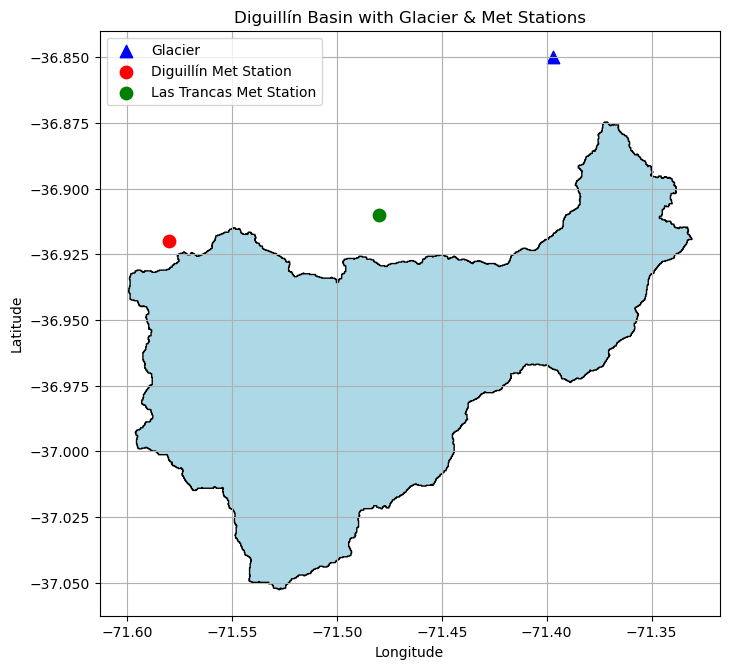

In [18]:
# path to basin shapefile
shapefile_path = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/polygon/polygon.shp' 
# File paths for your CAMELS basin data
# Here using: Cuenca 8130002 - Rio Diguillin En San Lorenzo (Atacalco) (Lat. -36.92, Lon. -71.58)
# Área: 204.4 km². Precip. anual media CR2MET: 2400 mm. Indice áridez: 0.4
# Cota (máx., media, punto salida): 3176, 1511, 715 m s.n.m.

# Load the shapefile using GeoPandas
basin_gdf = gpd.read_file(shapefile_path)

# Glacier and station coordinates (lat, lon)
glacier_coords = (-36.85, -71.397)   # (Lat, Lon)
diguillin_station_coords = (-36.92, -71.58)    # (Lat, Lon)
trancas_station_coords = (-36.91, -71.48)    # (Lat, Lon)

# Elevations in meters
glacier_elev = 2614
station_elev_diguillin = 715
station_elev_trancas = 1248

# Calculate aerial distance (in km)
diguillin_distance_km = geodesic(glacier_coords, diguillin_station_coords).km
trancas_distance_km = geodesic(glacier_coords, trancas_station_coords).km

# Calculate elevation difference (in m)
elev_diff_diguillin = glacier_elev - station_elev_diguillin
elev_diff_trancas = glacier_elev - station_elev_trancas

print(f"Distance between glacier and Diguillin met station: {diguillin_distance_km:.2f} km")
print(f"Distance between glacier and Las Trancas met station: {trancas_distance_km:.2f} km")
print(f"Elevation difference Glacier to Diguillin: {elev_diff_diguillin} m")
print(f"Elevation difference Glacier to Las Trancas: {elev_diff_trancas} m")

# Plot the basin polygon
fig, ax = plt.subplots(figsize=(8, 8))
basin_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Plot glacier location
ax.scatter(glacier_coords[1], glacier_coords[0], color='blue', s=80, marker='^', label="Glacier")

# Plot meteorological station location
ax.scatter(diguillin_station_coords[1], diguillin_station_coords[0], color='red', s=80, marker='o', label="Diguillín Met Station")
ax.scatter(trancas_station_coords[1], trancas_station_coords[0], color='green', s=80, marker='o', label="Las Trancas Met Station")


# Add labels and grid
ax.set_title("Diguillín Basin with Glacier & Met Stations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.legend()

plt.show()


## Timeseries analysis of precip and temp data


=== Temperature analysis: Diguillin ===
Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.02/yr, MK p=9.276192924900784e-09, significant


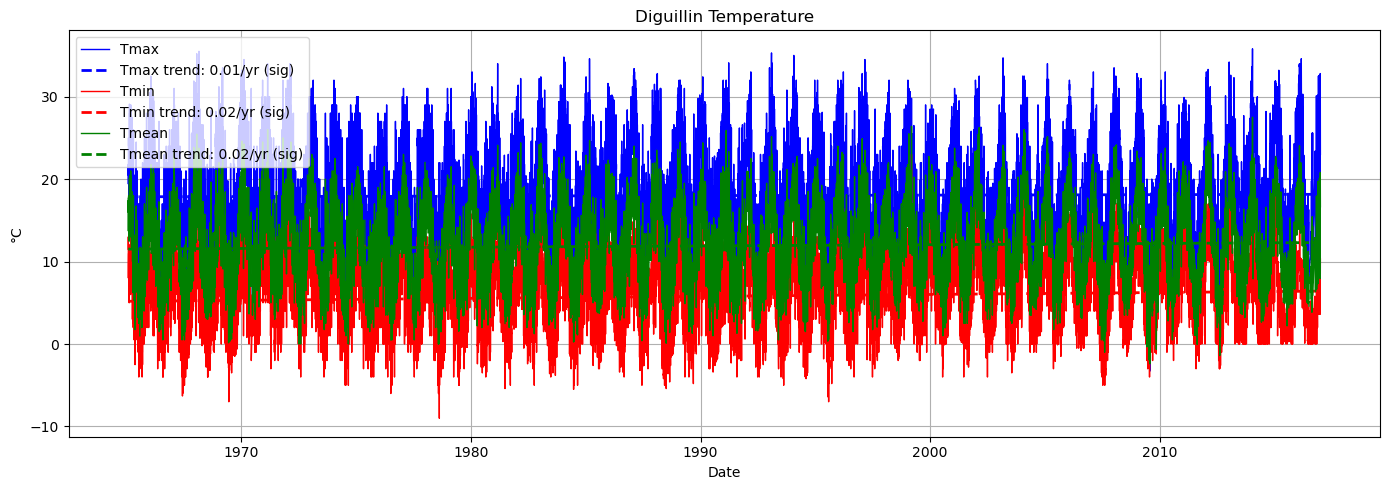


=== Precipitation analysis: Diguillin ===
Diguillin Precip: slope=-1.28/yr, MK p=0.11418692547453557, not significant


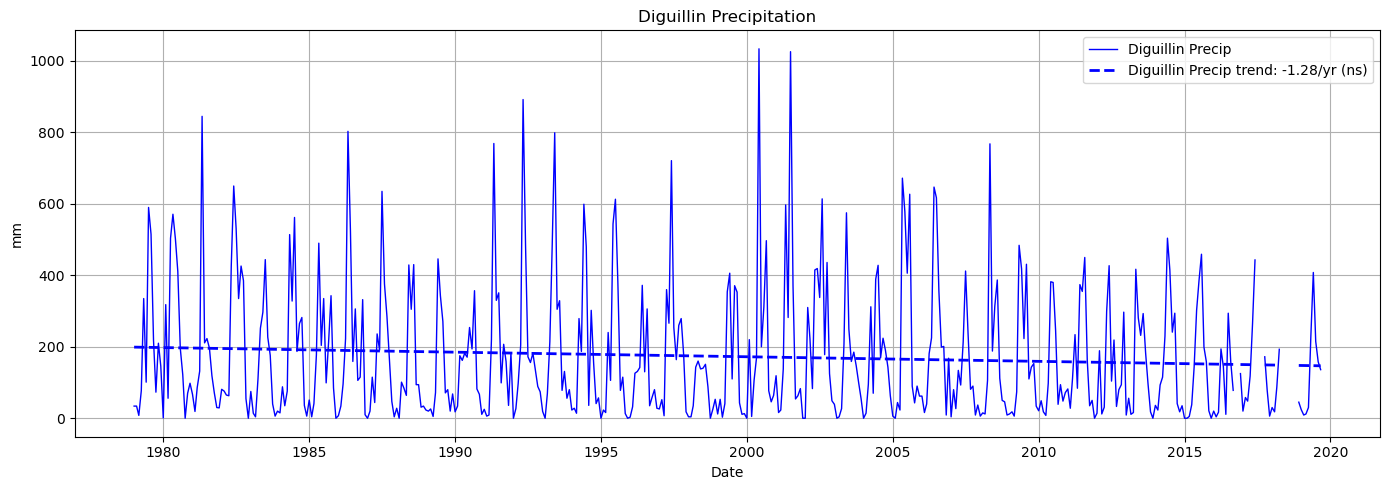


=== Precipitation analysis: Las Trancas ===
Las Trancas Precip: slope=-3.59/yr, MK p=4.789328961329886e-05, significant


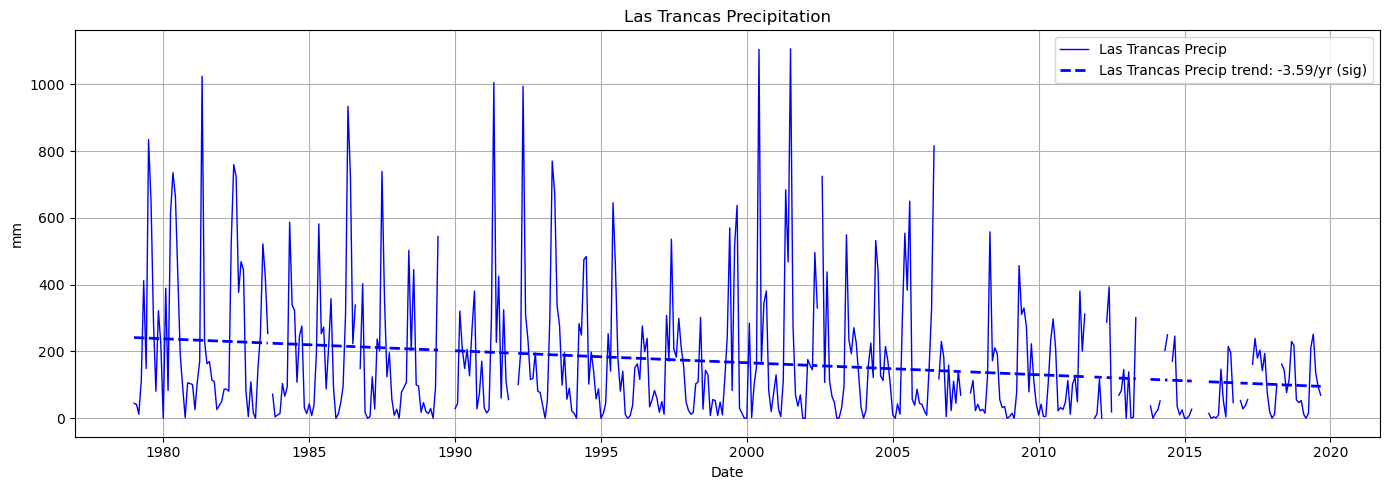

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

# ------------------- FILE PATHS -------------------

# Temperature station (Diguillin)
temp_stations = {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

# Precipitation stations
precip_stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

# ------------------- FUNCTIONS -------------------

def load_temp_csv(filepath):
    """Load daily temperature CSV with columns agno, mes, dia, valor."""
    df = pd.read_csv(filepath, sep=None, engine='python')  # auto-detect separator
    df.rename(columns=lambda x: x.strip(), inplace=True)
    for col in ["agno","mes","dia","valor"]:
        if col not in df.columns:
            raise KeyError(f"Expected column {col} not found in {filepath}")
    df["Fecha"] = pd.to_datetime(dict(year=df["agno"], month=df["mes"], day=df["dia"]))
    df.set_index("Fecha", inplace=True)
    df = df["valor"].rename(filepath.split("/")[-1])
    return df

def load_precip_csv(filepath):
    """Load monthly precipitation CSV and filter out -9999."""
    df = pd.read_csv(filepath, parse_dates=["Fecha"])
    df.rename(columns=lambda x: x.strip(), inplace=True)
    # Assume first numeric column after 'Fecha' is the measurement
    val_col = df.columns[1]
    df[val_col] = pd.to_numeric(df[val_col], errors='coerce')
    df[val_col].replace(-9999, np.nan, inplace=True)
    df.set_index("Fecha", inplace=True)
    return df[val_col]

def compute_trend(series):
    """Compute linear regression trend and Mann-Kendall test."""
    valid = series.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=series.index), 0, None
    x = valid.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
    y = valid.values
    model = LinearRegression()
    model.fit(x, y)
    slope_per_year = model.coef_[0] * 365.25
    mk_res = mk.original_test(y)
    
    trend_line = pd.Series(index=series.index, dtype=float)
    trend_line[valid.index] = model.predict(x)
    return trend_line, slope_per_year, mk_res

def plot_timeseries(series_dict, title, ylabel):
    """Plot multiple series with trendlines."""
    plt.figure(figsize=(14,5))
    colors = ['blue','red','green','orange','purple','brown','cyan']
    for i, (label, series) in enumerate(series_dict.items()):
        trend_line, slope, mk_res = compute_trend(series)
        plt.plot(series.index, series, color=colors[i%len(colors)], lw=1, label=label)
        plt.plot(trend_line.index, trend_line, '--', color=colors[i%len(colors)],
                 lw=2, label=f"{label} trend: {slope:.2f}/yr ({'sig' if mk_res and mk_res.p<0.1 else 'ns'})")
        print(f"{label}: slope={slope:.2f}/yr, MK p={mk_res.p if mk_res else 'NA'}, {'significant' if mk_res and mk_res.p<0.1 else 'not significant'}")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

# 1. Temperature analysis
for station_name, paths in temp_stations.items():
    print(f"\n=== Temperature analysis: {station_name} ===")
    df_max = load_temp_csv(paths["Tmax"])
    df_min = load_temp_csv(paths["Tmin"])
    df_mean = (df_max + df_min) / 2
    temp_dict = {"Tmax": df_max, "Tmin": df_min, "Tmean": df_mean}
    plot_timeseries(temp_dict, f"{station_name} Temperature", "°C")

# 2. Precipitation analysis
for station_name, path in precip_stations.items():
    print(f"\n=== Precipitation analysis: {station_name} ===")
    precip_series = load_precip_csv(path)
    plot_timeseries({f"{station_name} Precip": precip_series}, f"{station_name} Precipitation", "mm")



=== Temperature analysis: Diguillin ===
Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.02/yr, MK p=9.276192924900784e-09, significant


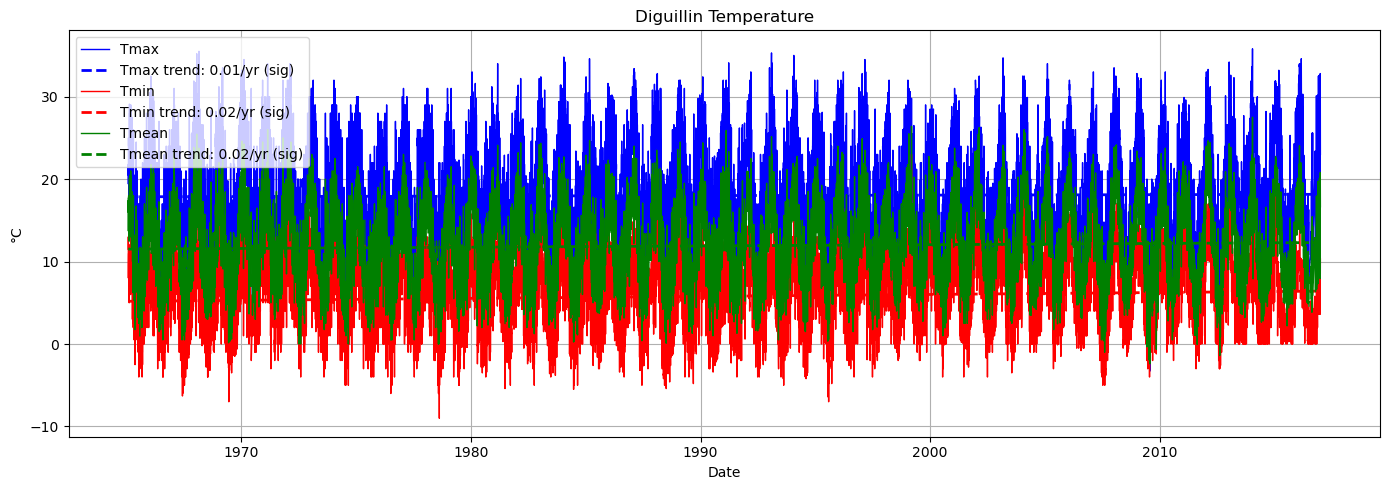


=== Precipitation analysis: Diguillin ===
Estacion_mm: slope=-1.28/yr, MK p=0.11418692547453557, not significant
CR2MET_v2_mm: slope=-1.36/yr, MK p=0.16110221791559942, not significant
CR2MET_v2.5_beta_mm: slope=-1.55/yr, MK p=0.12706451160067234, not significant
MSWEP_v2.8_mm: slope=-0.97/yr, MK p=0.06069569490450699, significant


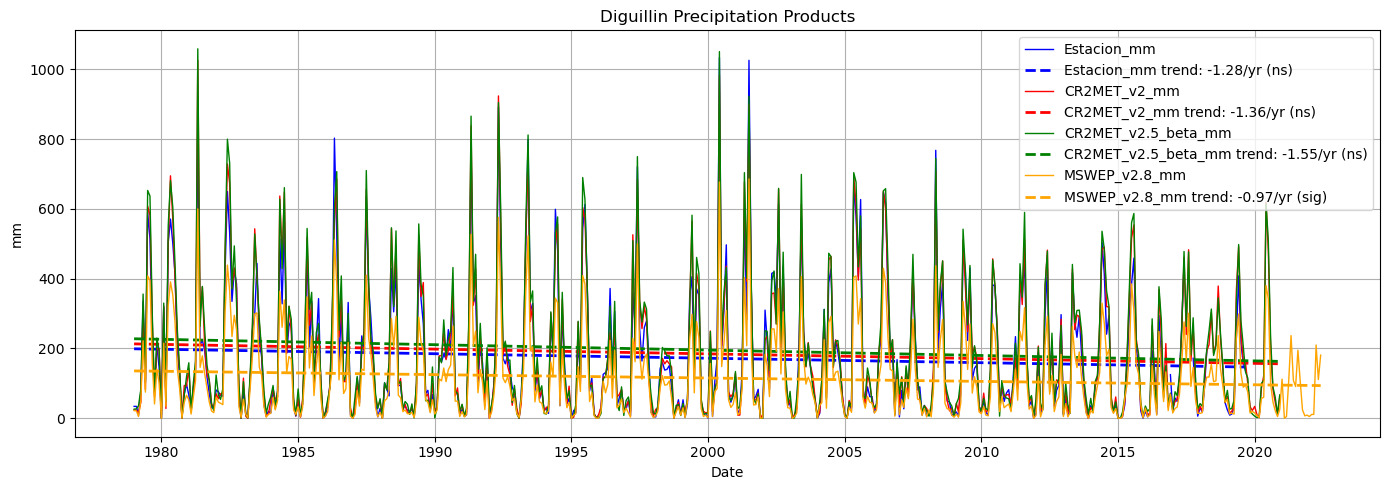


=== Precipitation analysis: Las Trancas ===
Estacion_mm: slope=-3.59/yr, MK p=4.789328961329886e-05, significant
CR2MET_v2_mm: slope=-1.57/yr, MK p=0.15617821852370106, not significant
CR2MET_v2.5_beta_mm: slope=-1.65/yr, MK p=0.13538219221268166, not significant
MSWEP_v2.8_mm: slope=-1.11/yr, MK p=0.05030680413542643, significant


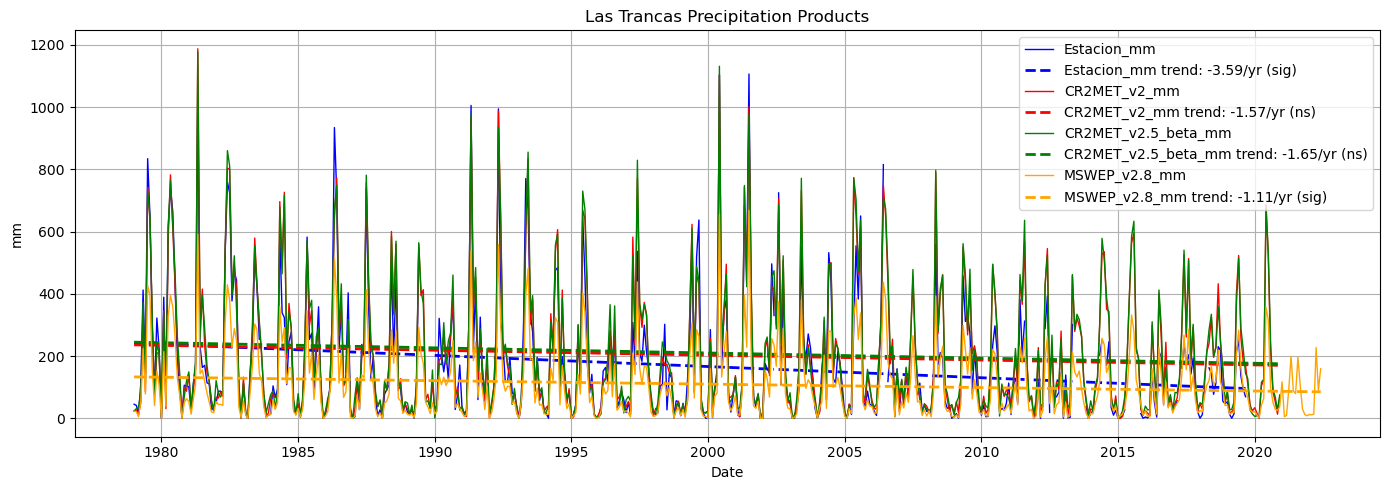

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

# ------------------- FILE PATHS -------------------

# Temperature station (Diguillin)
temp_stations = {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

# Precipitation stations
precip_stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

# Precipitation columns to include
precip_columns = ["Estacion_mm", "CR2MET_v2_mm", "CR2MET_v2.5_beta_mm", "MSWEP_v2.8_mm"]

# ------------------- FUNCTIONS -------------------

def load_temp_csv(filepath):
    """Load daily temperature CSV with columns agno, mes, dia, valor."""
    df = pd.read_csv(filepath, sep=None, engine='python')  # auto-detect separator
    df.rename(columns=lambda x: x.strip(), inplace=True)
    for col in ["agno","mes","dia","valor"]:
        if col not in df.columns:
            raise KeyError(f"Expected column {col} not found in {filepath}")
    df["Fecha"] = pd.to_datetime(dict(year=df["agno"], month=df["mes"], day=df["dia"]))
    df.set_index("Fecha", inplace=True)
    df = df["valor"].rename(filepath.split("/")[-1])
    return df

def load_precip_csv(filepath, columns):
    """Load monthly precipitation CSV, filter out -9999, and keep requested columns."""
    df = pd.read_csv(filepath, parse_dates=["Fecha"])
    df.rename(columns=lambda x: x.strip(), inplace=True)
    df.set_index("Fecha", inplace=True)
    df.replace(-9999, np.nan, inplace=True)
    available_cols = [col for col in columns if col in df.columns]
    return df[available_cols]

def compute_trend(series):
    """Compute linear regression trend and Mann-Kendall test, ignoring NaNs."""
    valid = series.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=series.index), 0, None
    x = valid.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
    y = valid.values
    model = LinearRegression()
    model.fit(x, y)
    slope_per_year = model.coef_[0] * 365.25
    mk_res = mk.original_test(y)
    
    trend_line = pd.Series(index=series.index, dtype=float)
    trend_line[valid.index] = model.predict(x)
    return trend_line, slope_per_year, mk_res

def plot_timeseries(series_dict, title, ylabel):
    """Plot multiple series with trendlines."""
    plt.figure(figsize=(14,5))
    colors = ['blue','red','green','orange','purple','brown','cyan']
    for i, (label, series) in enumerate(series_dict.items()):
        trend_line, slope, mk_res = compute_trend(series)
        plt.plot(series.index, series, color=colors[i%len(colors)], lw=1, label=label)
        plt.plot(trend_line.index, trend_line, '--', color=colors[i%len(colors)],
                 lw=2, label=f"{label} trend: {slope:.2f}/yr ({'sig' if mk_res and mk_res.p<0.1 else 'ns'})")
        print(f"{label}: slope={slope:.2f}/yr, MK p={mk_res.p if mk_res else 'NA'}, {'significant' if mk_res and mk_res.p<0.1 else 'not significant'}")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

# 1. Temperature analysis
for station_name, paths in temp_stations.items():
    print(f"\n=== Temperature analysis: {station_name} ===")
    df_max = load_temp_csv(paths["Tmax"])
    df_min = load_temp_csv(paths["Tmin"])
    df_mean = (df_max + df_min) / 2
    temp_dict = {"Tmax": df_max, "Tmin": df_min, "Tmean": df_mean}
    plot_timeseries(temp_dict, f"{station_name} Temperature", "°C")

# 2. Precipitation analysis (station + reconstruction products)
for station_name, path in precip_stations.items():
    print(f"\n=== Precipitation analysis: {station_name} ===")
    precip_series_dict = load_precip_csv(path, precip_columns)
    plot_timeseries(precip_series_dict.to_dict(orient='series'), f"{station_name} Precipitation Products", "mm")


## Simple OLS analysis of CAMELS-C: gridded data (no pre-whitening):


=== Temperature analysis: Diguillin ===
Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.03/yr, MK p=9.276192924900784e-09, significant


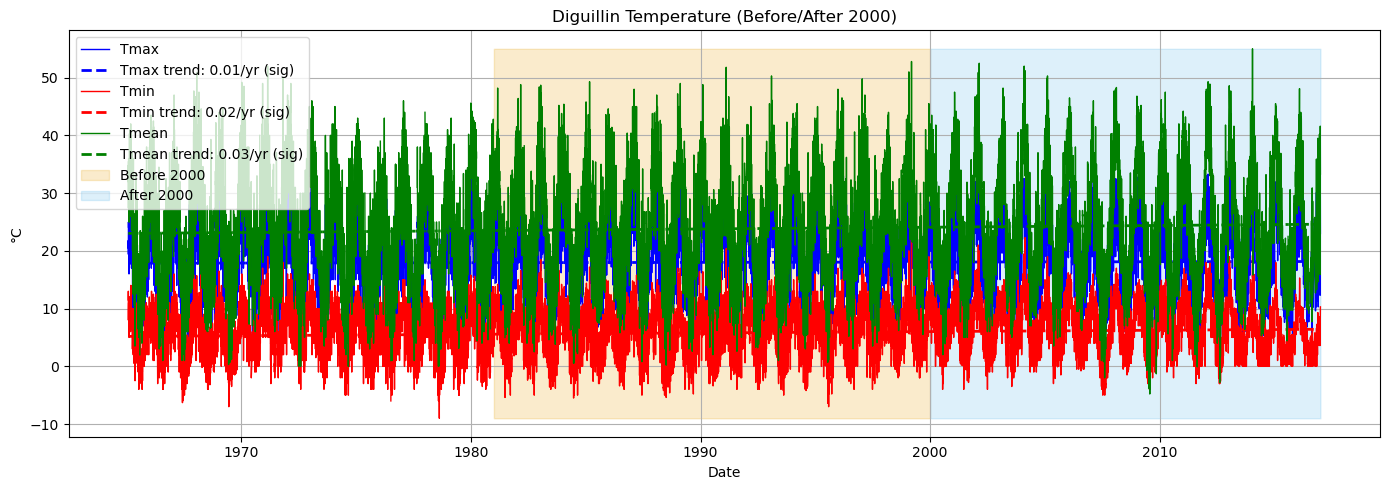

Tmax: slope=0.01/yr, MK p=0.07540740892518949, significant
Tmin: slope=0.02/yr, MK p=0.0, significant
Tmean: slope=0.03/yr, MK p=9.276192924900784e-09, significant


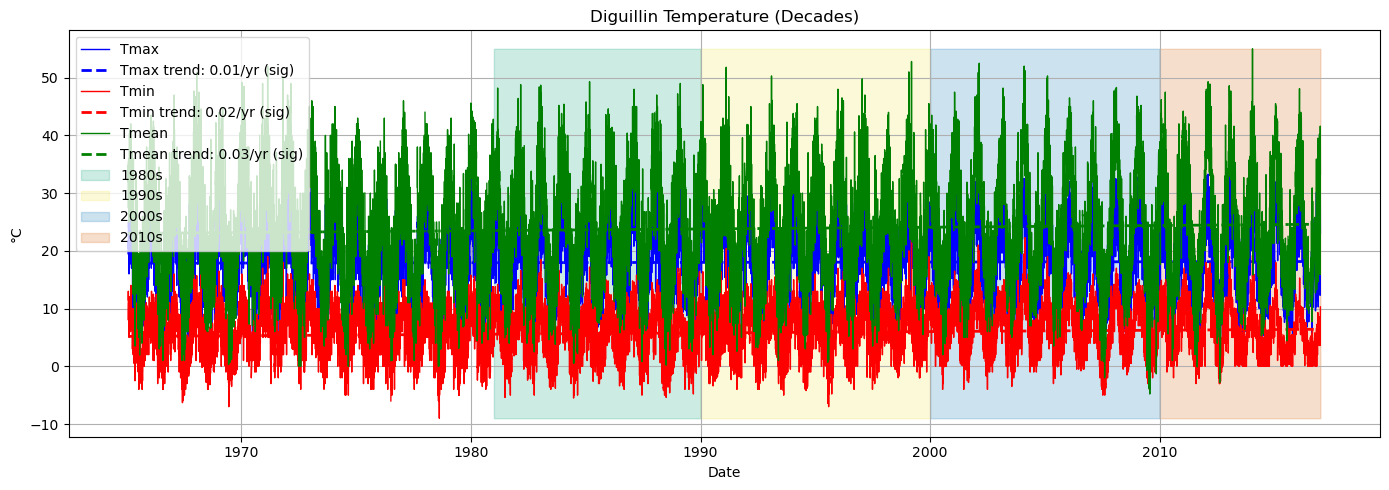


=== Precipitation analysis: Diguillin ===
Estacion_mm: slope=-1.28/yr, MK p=0.11418692547453557, not significant
CR2MET_v2_mm: slope=-1.36/yr, MK p=0.16110221791559942, not significant
CR2MET_v2.5_beta_mm: slope=-1.55/yr, MK p=0.12706451160067234, not significant
MSWEP_v2.8_mm: slope=-0.97/yr, MK p=0.06069569490450699, significant


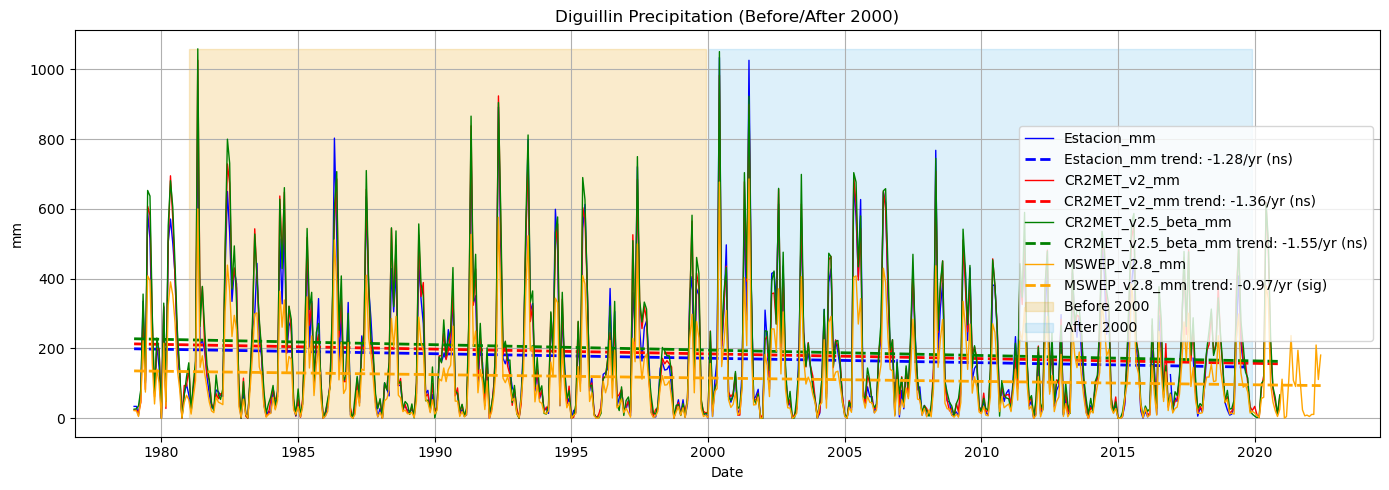

Estacion_mm: slope=-1.28/yr, MK p=0.11418692547453557, not significant
CR2MET_v2_mm: slope=-1.36/yr, MK p=0.16110221791559942, not significant
CR2MET_v2.5_beta_mm: slope=-1.55/yr, MK p=0.12706451160067234, not significant
MSWEP_v2.8_mm: slope=-0.97/yr, MK p=0.06069569490450699, significant


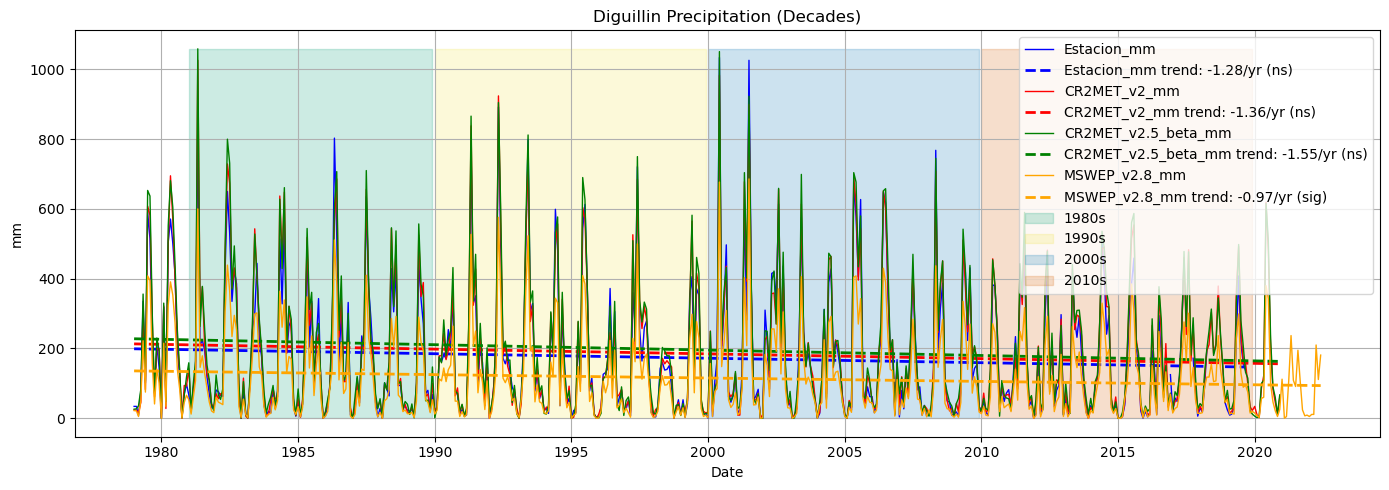


=== Precipitation analysis: Las Trancas ===
Estacion_mm: slope=-3.59/yr, MK p=4.789328961329886e-05, significant
CR2MET_v2_mm: slope=-1.57/yr, MK p=0.15617821852370106, not significant
CR2MET_v2.5_beta_mm: slope=-1.65/yr, MK p=0.13538219221268166, not significant
MSWEP_v2.8_mm: slope=-1.11/yr, MK p=0.05030680413542643, significant


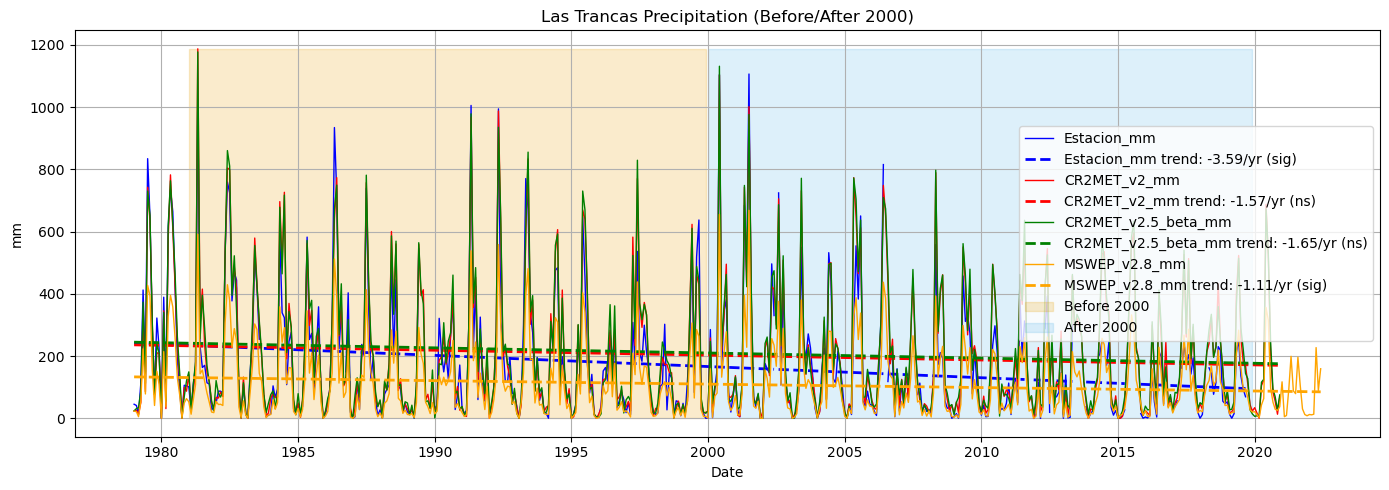

Estacion_mm: slope=-3.59/yr, MK p=4.789328961329886e-05, significant
CR2MET_v2_mm: slope=-1.57/yr, MK p=0.15617821852370106, not significant
CR2MET_v2.5_beta_mm: slope=-1.65/yr, MK p=0.13538219221268166, not significant
MSWEP_v2.8_mm: slope=-1.11/yr, MK p=0.05030680413542643, significant


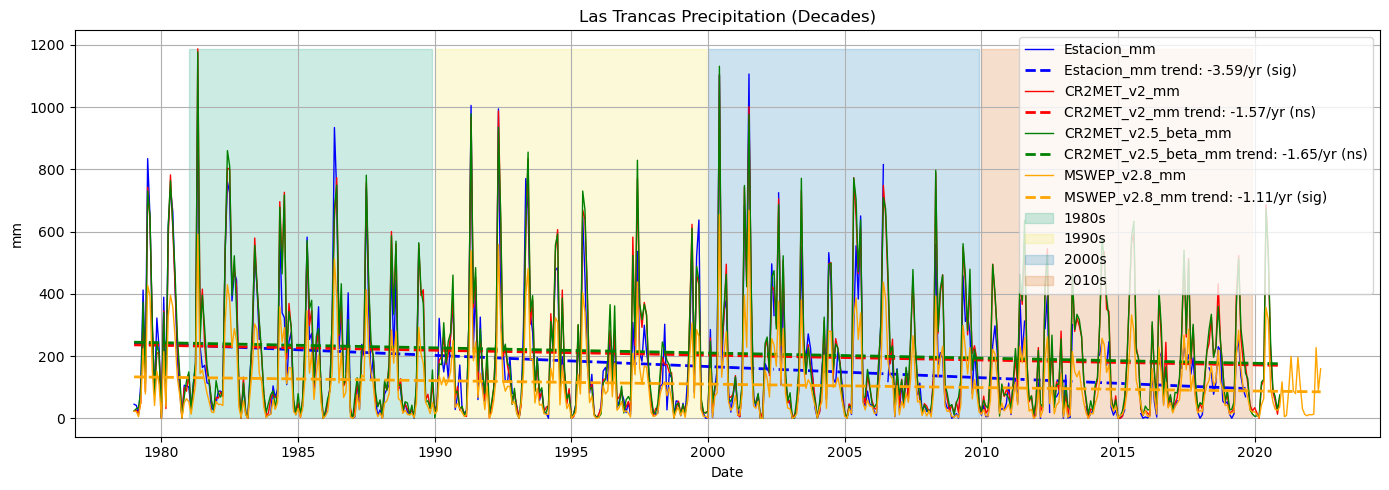

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

# ------------------- FILE PATHS -------------------

# Temperature station (Diguillin)
temp_stations = {
    "Diguillin": {
        "Tmax": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_max_diguillin.csv",
        "Tmin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/temp_min_diguillin.csv"
    }
}

# Precipitation stations
precip_stations = {
    "Diguillin": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Diguillin_codigo[C08130006].csv",
    "Las Trancas": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/CR2_station_data/pcp_mensual_mm_estacion_Las Trancas_codigo[C08130004].csv"
}

# Precipitation columns to include
precip_columns = ["Estacion_mm", "CR2MET_v2_mm", "CR2MET_v2.5_beta_mm", "MSWEP_v2.8_mm"]

# ------------------- PERIODS -------------------
cb_palette = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#999999']

before_after_2000 = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1999-12-31'), 'Before 2000', cb_palette[0]),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2019-12-31'), 'After 2000', cb_palette[1]),
]

decades = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1989-12-31'), '1980s', cb_palette[2]),
    (pd.Timestamp('1990-01-01'), pd.Timestamp('1999-12-31'), '1990s', cb_palette[3]),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2009-12-31'), '2000s', cb_palette[4]),
    (pd.Timestamp('2010-01-01'), pd.Timestamp('2019-12-31'), '2010s', cb_palette[5]),
]

# ------------------- FUNCTIONS -------------------

def load_temp_csv(filepath):
    """Load daily temperature CSV with columns agno, mes, dia, valor."""
    df = pd.read_csv(filepath, sep=None, engine='python')  # auto-detect separator
    df.rename(columns=lambda x: x.strip(), inplace=True)
    for col in ["agno","mes","dia","valor"]:
        if col not in df.columns:
            raise KeyError(f"Expected column {col} not found in {filepath}")
    df["Fecha"] = pd.to_datetime(dict(year=df["agno"], month=df["mes"], day=df["dia"]))
    df.set_index("Fecha", inplace=True)
    return df["valor"]

def load_precip_csv(filepath, columns):
    """Load monthly precipitation CSV and filter out -9999."""
    df = pd.read_csv(filepath, parse_dates=["Fecha"])
    df.rename(columns=lambda x: x.strip(), inplace=True)
    df.set_index("Fecha", inplace=True)
    df = df[columns].replace(-9999, np.nan)
    return df

def compute_trend(series):
    """Compute linear regression trend and Mann-Kendall test."""
    valid = series.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=series.index), 0, None
    x = valid.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
    y = valid.values
    model = LinearRegression()
    model.fit(x, y)
    slope_per_year = model.coef_[0] * 365.25
    trend_line = pd.Series(index=series.index, dtype=float)
    trend_line[valid.index] = model.predict(x)
    mk_res = mk.original_test(y)
    return trend_line, slope_per_year, mk_res

def plot_with_trends_and_periods(df, title, ylabel, periods):
    """Plot multiple series with trendlines and shaded periods."""
    plt.figure(figsize=(14,5))
    colors = ['blue','red','green','orange','purple','brown','cyan']
    for i, col in enumerate(df.columns):
        series = df[col]
        trend_line, slope, mk_res = compute_trend(series)
        plt.plot(series.index, series, color=colors[i%len(colors)], lw=1, label=col)
        plt.plot(trend_line.index, trend_line, '--', color=colors[i%len(colors)],
                 lw=2, label=f"{col} trend: {slope:.2f}/yr ({'sig' if mk_res and mk_res.p<0.1 else 'ns'})")
        print(f"{col}: slope={slope:.2f}/yr, MK p={mk_res.p if mk_res else 'NA'}, {'significant' if mk_res and mk_res.p<0.1 else 'not significant'}")
    
    # Shaded periods
    series_min = df.min().min()
    series_max = df.max().max()
    for i, (start, end, label, col) in enumerate(periods):
        plt.fill_between(df.index, series_min, series_max,
                         where=(df.index>=start) & (df.index<=end),
                         color=col, alpha=0.2, label=label)
    
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

# 1. Temperature analysis
for station_name, paths in temp_stations.items():
    print(f"\n=== Temperature analysis: {station_name} ===")
    df_max = load_temp_csv(paths["Tmax"]).rename("Tmax")
    df_min = load_temp_csv(paths["Tmin"]).rename("Tmin")
    df_mean = (df_max + df_min).rename("Tmean")
    temp_df = pd.concat([df_max, df_min, df_mean], axis=1)
    
    # Plot Before/After 2000
    plot_with_trends_and_periods(temp_df, f"{station_name} Temperature (Before/After 2000)", "°C", before_after_2000)
    
    # Plot decadal means
    plot_with_trends_and_periods(temp_df, f"{station_name} Temperature (Decades)", "°C", decades)

# 2. Precipitation analysis
for station_name, path in precip_stations.items():
    print(f"\n=== Precipitation analysis: {station_name} ===")
    precip_df = load_precip_csv(path, precip_columns)
    
    # Plot Before/After 2000
    plot_with_trends_and_periods(precip_df, f"{station_name} Precipitation (Before/After 2000)", "mm", before_after_2000)
    
    # Plot decadal means
    plot_with_trends_and_periods(precip_df, f"{station_name} Precipitation (Decades)", "mm", decades)
